In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("online_advertising_performance_data.csv")   # Load dataset
df.head() 

,month,day,campaign_number,user_engagement,banner,placement,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount,Unnamed: 12,Unnamed: 13
0,April,1,camp 1,High,160 x 600,abc,4,0.0060,0,0.0000,0,0.0000,NaN,NaN
1,April,1,camp 1,High,160 x 600,def,20170,26.7824,158,28.9717,23,1972.4602,NaN,NaN
2,April,1,camp 1,High,160 x 600,ghi,14701,27.6304,158,28.9771,78,2497.2636,NaN,NaN
3,April,1,camp 1,High,160 x 600,mno,171259,216.8750,1796,329.4518,617,24625.3234,NaN,NaN
4,April,1,camp 1,Low,160 x 600,def,552,0.0670,1,0.1834,0,0.0000,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15408 entries, 0 to 15407
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   month                    15408 non-null  object 
 1   day                      15408 non-null  int64  
 2   campaign_number          15408 non-null  object 
 3   user_engagement          15408 non-null  object 
 4   banner                   15408 non-null  object 
 5   placement                14995 non-null  object 
 6   displays                 15408 non-null  int64  
 7   cost                     15408 non-null  float64
 8   clicks                   15408 non-null  int64  
 9   revenue                  15408 non-null  float64
 10  post_click_conversions   15408 non-null  int64  
 11  post_click_sales_amount  15408 non-null  float64
 12  Unnamed: 12              0 non-null      float64
 13  Unnamed: 13              0 non-null      float64
dtypes: float64(5), int64(4

In [4]:
df.describe()

,day,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount,Unnamed: 12,Unnamed: 13
count,15408.000000,15408.000000,15408.000000,15408.000000,15408.000000,15408.000000,15408.000000,0.0,0.0
mean,15.518886,15512.573014,11.370262,161.788487,17.929943,42.300623,2123.288058,NaN,NaN
std,8.740909,44392.392890,45.369499,728.276911,96.781834,213.685660,10523.029607,NaN,NaN
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,8.000000,78.000000,0.024000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,15.000000,1182.000000,0.339850,6.000000,0.483950,0.000000,0.000000,NaN,NaN
75%,23.000000,8960.250000,2.536225,53.000000,3.839800,3.000000,163.351200,NaN,NaN
max,31.000000,455986.000000,556.704800,14566.000000,2096.211600,3369.000000,199930.318000,NaN,NaN


In [5]:
df.shape

(15408, 14)

#  Data Cleaning

In [6]:
df = df.drop(['Unnamed: 12', 'Unnamed: 13'], axis=1)

In [7]:
df['placement'] = df['placement'].fillna('Unknown')

In [8]:
df.isnull().sum()

month                      0
day                        0
campaign_number            0
user_engagement            0
banner                     0
placement                  0
displays                   0
cost                       0
clicks                     0
revenue                    0
post_click_conversions     0
post_click_sales_amount    0
dtype: int64

In [9]:
df.duplicated().sum()

5

In [10]:
df.drop_duplicates(inplace= True)

# Feature Engineering

In [11]:
df['month'] = pd.to_datetime(df['month'], format='%B').dt.month

In [12]:
# ClickThrough Rate
df['CTR'] = df['clicks'] / df['displays']

In [13]:
# Cost per Click
df['CPC'] = df['cost'] / df['clicks']

In [14]:
# Rate of Intrest
df['ROI'] = df['revenue'] / df['cost']

In [15]:
# Conversion Rate
df["conversion_rate"] = df["post_click_conversions"] / df["clicks"]

In [16]:
# Revenue Per Click
df["RPC"] = df["revenue"] / df["clicks"]

In [17]:
# Handle inf and NaN values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# Exploratory Data Analysis (EDA)

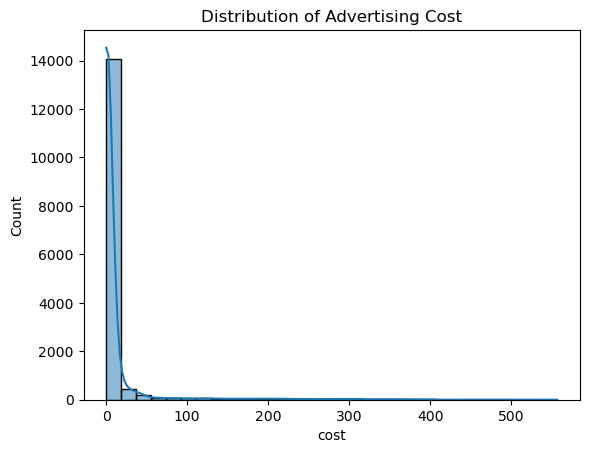

In [18]:
# Cost Distribution
sns.histplot(df["cost"], bins=30, kde=True)
plt.title("Distribution of Advertising Cost")
plt.show()


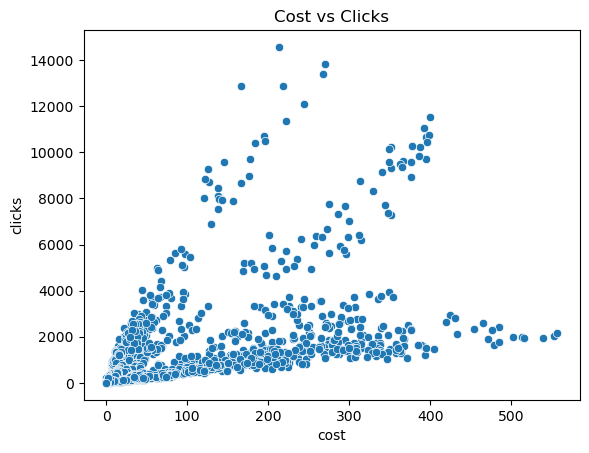

In [19]:
# Cost vs Clicks
sns.scatterplot(data=df, x="cost", y="clicks")
plt.title("Cost vs Clicks")
plt.show()

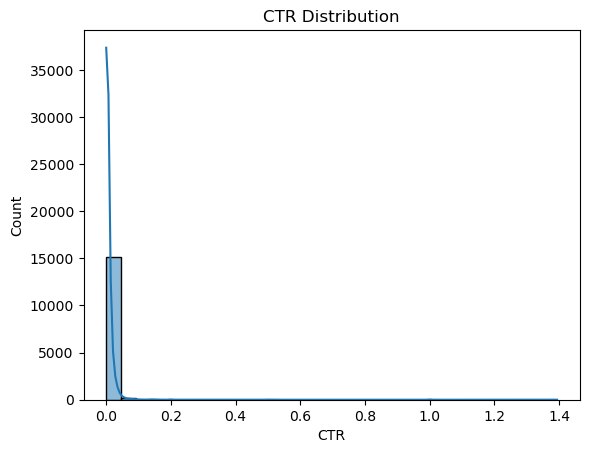

In [20]:
#CTR Distribution
sns.histplot(df["CTR"], bins=30, kde=True)
plt.title("CTR Distribution")
plt.show()

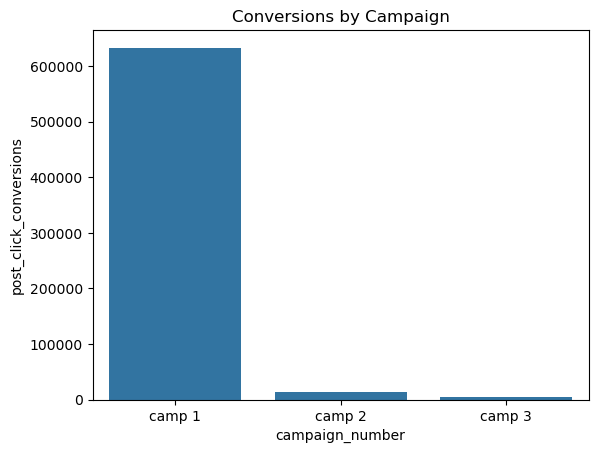

In [21]:
# Campaign-wise Conversions
campaign_conv = df.groupby("campaign_number")["post_click_conversions"].sum().reset_index()

sns.barplot(data=campaign_conv, x="campaign_number", y="post_click_conversions")
plt.title("Conversions by Campaign")
plt.show()


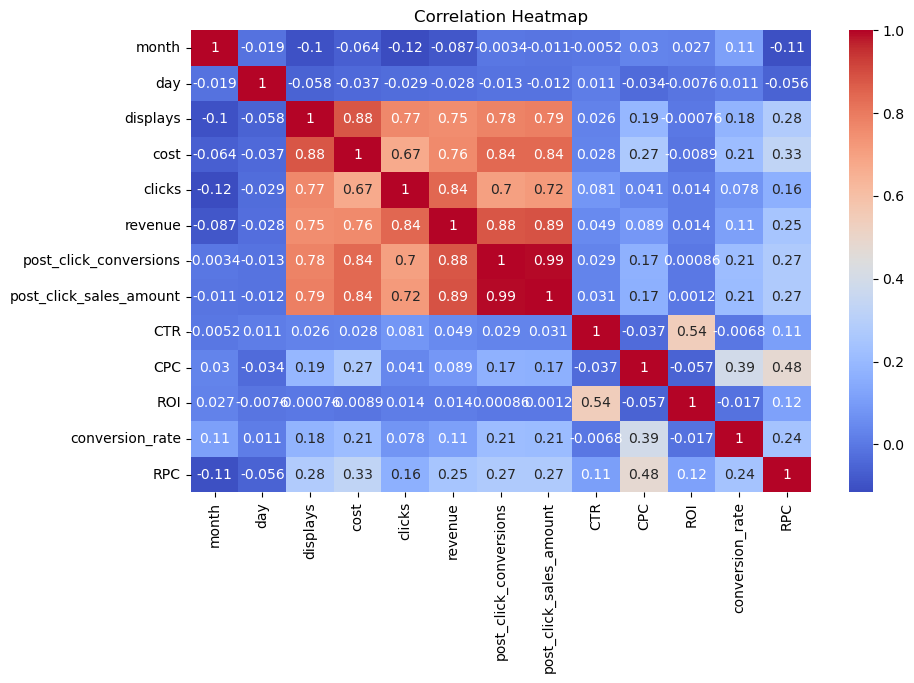

In [22]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Statistical Analysis

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15403 entries, 0 to 15402
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   month                    15403 non-null  int32  
 1   day                      15403 non-null  int64  
 2   campaign_number          15403 non-null  object 
 3   user_engagement          15403 non-null  object 
 4   banner                   15403 non-null  object 
 5   placement                15403 non-null  object 
 6   displays                 15403 non-null  int64  
 7   cost                     15403 non-null  float64
 8   clicks                   15403 non-null  int64  
 9   revenue                  15403 non-null  float64
 10  post_click_conversions   15403 non-null  int64  
 11  post_click_sales_amount  15403 non-null  float64
 12  CTR                      15403 non-null  float64
 13  CPC                      15403 non-null  float64
 14  ROI                      15

In [24]:
numeric_cols = [
    "cost",
    "clicks",
    "displays",
    "revenue",
    "post_click_conversions",
    "post_click_sales_amount",
    "CTR",
    "CPC",
    "conversion_rate",
    "RPC"
]

df[numeric_cols].head()

,cost,clicks,displays,revenue,post_click_conversions,post_click_sales_amount,CTR,CPC,conversion_rate,RPC
0,0.0060,0,4,0.0000,0,0.0000,0.000000,0.000000,0.000000,0.000000
1,26.7824,158,20170,28.9717,23,1972.4602,0.007833,0.169509,0.145570,0.183365
2,27.6304,158,14701,28.9771,78,2497.2636,0.010748,0.174876,0.493671,0.183399
3,216.8750,1796,171259,329.4518,617,24625.3234,0.010487,0.120754,0.343541,0.183436
4,0.0670,1,552,0.1834,0,0.0000,0.001812,0.067000,0.000000,0.183400


In [25]:
print("Mean Revenue:", df['revenue'].mean())
print("Median Revenue:", df['revenue'].median())
print("Std Dev:", df['revenue'].std())

Mean Revenue: 17.935636947347916
Median Revenue: 0.4842
Std Dev: 96.79702530048633


In [26]:
desc_stats = df[numeric_cols].describe()
desc_stats.T

,count,mean,std,min,25%,50%,75%,max
cost,15403.0,11.373902,45.376413,0.0,0.02405,0.340200,2.537150,556.704800
clicks,15403.0,161.840226,728.389447,0.0,0.00000,6.000000,53.000000,14566.000000
displays,15403.0,15517.383691,44398.791785,0.0,78.00000,1182.000000,8969.500000,455986.000000
revenue,15403.0,17.935637,96.797025,0.0,0.00000,0.484200,3.841800,2096.211600
post_click_conversions,15403.0,42.313965,213.719056,0.0,0.00000,0.000000,3.000000,3369.000000
post_click_sales_amount,15403.0,2123.963529,10524.670688,0.0,0.00000,0.000000,163.502650,199930.318000
CTR,15403.0,0.008107,0.031778,0.0,0.00000,0.003606,0.008547,1.393939
CPC,15403.0,0.055735,0.079186,0.0,0.00000,0.025043,0.080850,1.241500
conversion_rate,15403.0,0.124881,0.390152,0.0,0.00000,0.000000,0.076923,16.000000
RPC,15403.0,0.063410,0.064132,0.0,0.00000,0.053300,0.106975,0.200000


In [27]:
from scipy.stats import pearsonr


In [28]:
corr, p_value = pearsonr(df['cost'], df['revenue'])
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.7605169899114146
P-value: 0.0


# Machine Learning Model

In [29]:
features = [
    "cost",
    "clicks",
    "displays",
    "CTR",
    "CPC",
    "conversion_rate",
    "RPC"]

In [30]:
target = "revenue"

In [31]:
X = df[features]
y = df[target]

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
from sklearn.ensemble import RandomForestRegressor

In [35]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [36]:
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score

In [38]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

MAE: 0.6706120146056465
MSE: 55.863862594820496


In [39]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.994376276083513
